# Mixed-variable optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim import minimize

from smt_optim.benchmarks.registry import get_problem

## Mixed-variable problem definition

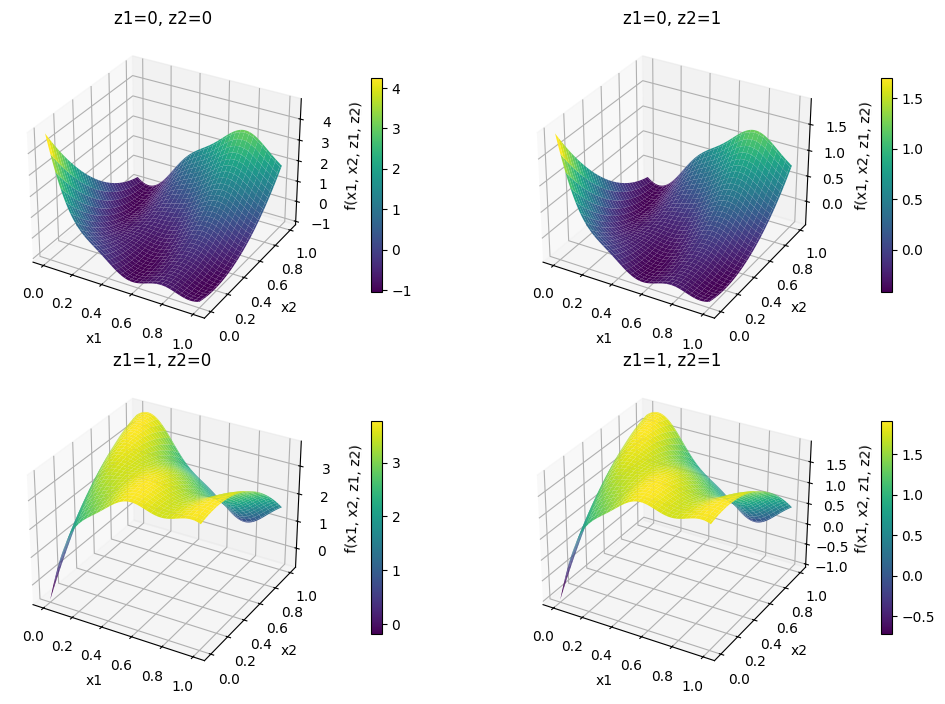

In [2]:
problem = get_problem("MixVarBranin")

x1 = np.linspace(0.0, 1.0, 101)
x2 = np.linspace(0.0, 1.0, 101)

X1, X2 = np.meshgrid(x1, x2)

z_combinations = [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1),
]

fig = plt.figure(figsize=(11, 7))

for i, (z1, z2) in enumerate(z_combinations, start=1):

    F = np.zeros_like(X1)

    for r in range(X1.shape[0]):
        for c in range(X1.shape[1]):
            x = np.array([X1[r, c], X2[r, c], z1, z2])
            F[r, c] = problem.objective(x)

    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(X1, X2, F, cmap="viridis", edgecolor="none")

    ax.set_title(f"z1={z1}, z2={z2}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("f(x1, x2, z1, z2)")

    fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1)

plt.tight_layout()
plt.show()


## Using the minimize API

In [3]:
problem.design_space

DesignSpace([FloatVariable(0, 1), FloatVariable(0, 1), CategoricalVariable([0, 1]), CategoricalVariable([0, 1])])

In [4]:

constraint = {
    "fun": [problem.constraint],
    "upper": 0.,
}

state = minimize(
    [problem.objective],
    problem.design_space,
    constraints=[constraint],
    max_iter=10,
    method="sego",
    driver_kwargs={"seed": 42}
)

state.get_best_sample()


          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1              6   -2.85423e-01      0.000e+00              1          0.638          1.640
             2              7   -2.85423e-01      0.000e+00              1          0.716          1.217
             3              8   -2.85423e-01      0.000e+00              1          0.646          2.239
             4              9   -2.85423e-01      0.000e+00              1          0.678          1.303
             5             10   -3.05276e-01      0.000e+00              1          0.681          1.232
             6             11   -3.05276e-01      0.000e+00              1          0.650          1.203
             7             12   -3.05276e-01      0.000e+00              1          0.609          1.094
             8             13   -7.48331e-01      0.000e+00              1          0.720          1.179
             9             14   -7.48331e-01      0.000

======= sample data =======
x =             [1.         0.43268085 0.         0.        ]
obj =           [-0.74833062]
cstr =          [-0.03268085]
eval_time =     [9.14699922e-06 2.09800055e-06]
------- meta data -------
iter =     8
budget =     13
fidelity =     0
rscv =     0.0